<a href="https://colab.research.google.com/github/JacekDrzycimski/6tunnel/blob/master/OCR_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Install Tesseract OCR and Dependencies
We first install the Tesseract system binary, pytesseract, and OpenCV.

In [1]:
!apt-get install -y tesseract-ocr
!pip install pytesseract opencv-python Pillow

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (5.3.4-1build5).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


### 2. Preprocessing & OCR Pipeline
To extract text from degraded documents, we can apply denoising and adaptive thresholding to maximize character contrast.

In [30]:
import cv2
import numpy as np
import pytesseract
from PIL import Image


def run_ocr_pipeline(image_path):
    # 1. Clean the image using the improved preprocessing function
    cleaned_img = preprocess_for_ocr_v2(image_path)

    # 2. Convert array to PIL Image
    pil_img = Image.fromarray(cleaned_img)

    # 3. Apply pytesseract (using PSM 3: fully automatic page segmentation)
    custom_config = r'--oem 3 --psm 3'
    extracted_text = pytesseract.image_to_string(pil_img, config=custom_config)

    return cleaned_img, extracted_text

### 2.5. Deskewing (Straightening Tilted Scans)
Often, old scans are tilted at an angle. To fix this, we can compute the orientation angle of the text blocks using minimum bounding boxes over the text contours and rotate the image to straighten it before OCR.

In [3]:
def deskew_image(image):
    # Threshold the image to get a binary representation of text vs background
    _, thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Find all coordinates where pixels are non-zero (text)
    coords = np.column_stack(np.where(thresh > 0))

    # Compute the minimum bounding box that contains all these coordinates
    angle = cv2.minAreaRect(coords)[-1]

    # Adjust the angle calculation based on cv2's coordinate system
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    # If the skew angle is negligible, do not rotate
    if abs(angle) < 0.5 or abs(angle) > 45:
        return image

    # Get rotation matrix and perform the affine transformation
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

    return rotated

Let's update the preprocessing pipeline function to include this new deskewing step.

In [4]:
import cv2
import numpy as np

def deskew_image(image):
    # Threshold the image to get a binary representation of text vs background
    _, thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Find all coordinates where pixels are non-zero (text)
    coords = np.column_stack(np.where(thresh > 0))

    # Compute the minimum bounding box that contains all these coordinates
    angle = cv2.minAreaRect(coords)[-1]

    # Adjust the angle calculation based on cv2's coordinate system
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    # If the skew angle is negligible, do not rotate
    if abs(angle) < 0.5 or abs(angle) > 45:
        return image

    # Get rotation matrix and perform the affine transformation
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

    return rotated

The `deskew_image` function takes an image as input and performs the following steps:

1.  **Thresholding**: Converts the image to a binary representation (black and white) to distinguish text from the background.
2.  **Coordinate Extraction**: Identifies all non-zero pixels, which represent text.
3.  **Minimum Bounding Box**: Calculates the smallest bounding box that encloses all text, and from this, determines the tilt angle.
4.  **Rotation**: If the detected angle is significant, it rotates the image to straighten the text, using cubic interpolation for quality and replicating border pixels.

In [5]:
def preprocess_for_ocr_v2(image_path):
    # Load image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # 1. Deskew the original scan first to avoid distortion
    img = deskew_image(img)

    # 2. Resize moderately (only if the image is too small; here 1.2x is safer)
    img = cv2.resize(img, None, fx=1.2, fy=1.2, interpolation=cv2.INTER_CUBIC)

    # 3. Denoise gently using Bilateral Filter to keep edges sharp
    denoised = cv2.bilateralFilter(img, 5, 50, 50)

    # 4. Adaptive Threshold with larger block size and constant tuning
    # Using threshold parameters that preserve bold letter strokes
    processed_img = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 10
    )

    return processed_img

The `preprocess_for_ocr_v2` function orchestrates the entire preprocessing pipeline:

1.  **Image Loading**: Loads the image from the specified `image_path` in grayscale.
2.  **Deskewing**: Calls `deskew_image` to correct any tilt in the image.
3.  **Resizing**: Resizes the image by a factor of 1.2 using cubic interpolation to potentially enhance smaller text for OCR.
4.  **Denoising**: Applies a bilateral filter to reduce noise while attempting to preserve the edges of the text, which is crucial for OCR accuracy.
5.  **Adaptive Thresholding**: Converts the image to black and white using adaptive thresholding. This method calculates different thresholds for different regions of the image, making it effective for images with varying lighting conditions or background noise. The parameters are tuned to preserve bold letter strokes.

In [6]:
def preprocess_for_ocr_v2(image_path):
    # Load image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # 1. Deskew the original scan first to avoid distortion
    img = deskew_image(img)

    # 2. Resize moderately (only if the image is too small; here 1.2x is safer)
    img = cv2.resize(img, None, fx=1.2, fy=1.2, interpolation=cv2.INTER_CUBIC)

    # 3. Denoise gently using Bilateral Filter to keep edges sharp
    denoised = cv2.bilateralFilter(img, 5, 50, 50)

    # 4. Adaptive Threshold with larger block size and constant tuning
    # Using threshold parameters that preserve bold letter strokes
    processed_img = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 10
    )

    return processed_img

### 3. Visualizing and Running the OCR Pipeline
Let's generate a synthetic "bad-quality" old document image (with background noise and fading) to demonstrate how our preprocessing improves OCR performance.

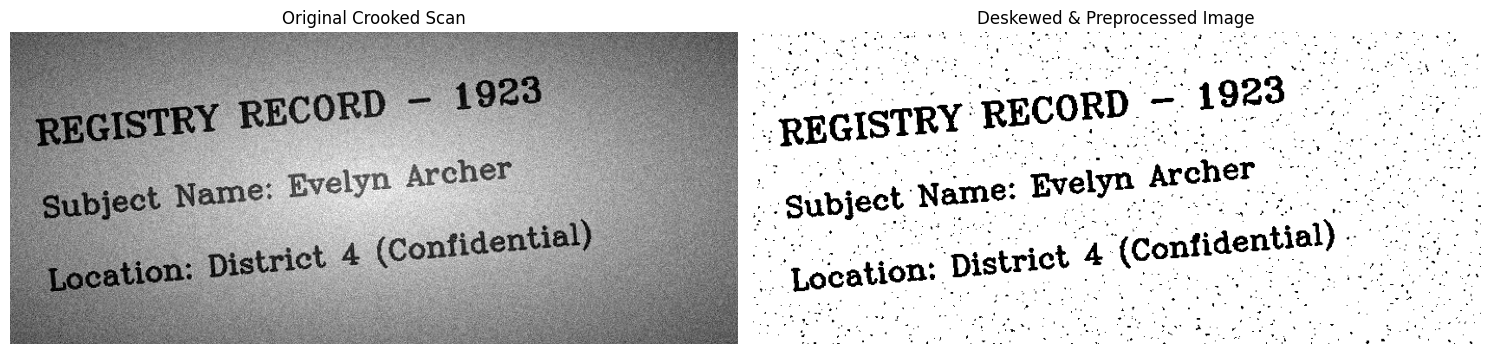


--- Extracted Text from OCR ---
_pncisTRY F ‘RECORD - _ “1928
- subject Neme: Evelyn Archer a :

istrict 4 4 (Gontsenti ae

“ Yocation: D




In [7]:
import matplotlib.pyplot as plt
import os

# Define paths
sample_image_path = 'old_record_sample_tilted.png'

# Create a mock "tilted" degraded image for demonstration
def create_mock_tilted_record(path, angle_tilt=5.0):
    # Create a blank white canvas
    img = np.ones((300, 700), dtype=np.uint8) * 230

    # Add mock faded text
    cv2.putText(img, "REGISTRY RECORD - 1923", (30, 80), cv2.FONT_HERSHEY_TRIPLEX, 1.1, (80, 80, 80), 2)
    cv2.putText(img, "Subject Name: Evelyn Archer", (30, 150), cv2.FONT_HERSHEY_COMPLEX, 0.9, (100, 100, 100), 2)
    cv2.putText(img, "Location: District 4 (Confidential)", (30, 220), cv2.FONT_HERSHEY_COMPLEX, 0.9, (90, 90, 90), 2)

    # Rotate the image slightly to simulate a crooked scan
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle_tilt, 1.0)
    img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

    # Simulate paper yellowing / uneven exposure (vignette gradient)
    x = np.linspace(-1, 1, img.shape[1])
    y = np.linspace(-1, 1, img.shape[0])
    x_matrix, y_matrix = np.meshgrid(x, y)
    gradient = np.sqrt(x_matrix**2 + y_matrix**2)
    gradient = cv2.resize(gradient, (img.shape[1], img.shape[0]))
    img = np.clip(img - (gradient * 100), 0, 255).astype(np.uint8)

    # Simulate speckle noise (dirt/stains on paper)
    noise = np.random.normal(0, 15, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Write to file
    cv2.imwrite(path, img)

# Generate the tilted mock record
create_mock_tilted_record(sample_image_path, angle_tilt=5.0)

try:
    # Run the updated pipeline containing deskewing (v2)
    cleaned_img = preprocess_for_ocr_v2(sample_image_path)

    # Run OCR on the corrected image
    pil_img = Image.fromarray(cleaned_img)
    custom_config = r'--oem 3 --psm 3'
    text_output = pytesseract.image_to_string(pil_img, config=custom_config)

    # Plot side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Original tilted image
    original_loaded = cv2.imread(sample_image_path)
    axes[0].imshow(cv2.cvtColor(original_loaded, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Crooked Scan")
    axes[0].axis('off')

    # Preprocessed & Deskewed image
    axes[1].imshow(cleaned_img, cmap='gray')
    axes[1].set_title("Deskewed & Preprocessed Image")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # Output extracted content
    print("\n--- Extracted Text from OCR ---")
    print(text_output if text_output.strip() else "[No text detected. Try tuning the adaptive threshold params!]")

except Exception as e:
    print(f"An error occurred during execution: {e}")

### 4. Evaluating & Visualizing OCR Accuracy Improvement
To quantitatively verify how much the preprocessing and deskewing steps help, let's run Tesseract on both the **raw original scan** and our **preprocessed image**, then plot the character matching accuracy against the expected ground truth text.

=== EXTRACTED TEXT COMPARISON ===

[RAW ORIGINAL SCAN OCR (Accuracy: 65.7%)]:
RECORD —
Archer

ot Name: Evelyn
trict 4 (Confidential)

[PREPROCESSED & DESKEWED OCR (Accuracy: 70.9%)]:
_pncisTRY F ‘RECORD - _ “1928
- subject Neme: Evelyn Archer a :

istrict 4 4 (Gontsenti ae

“ Yocation: D



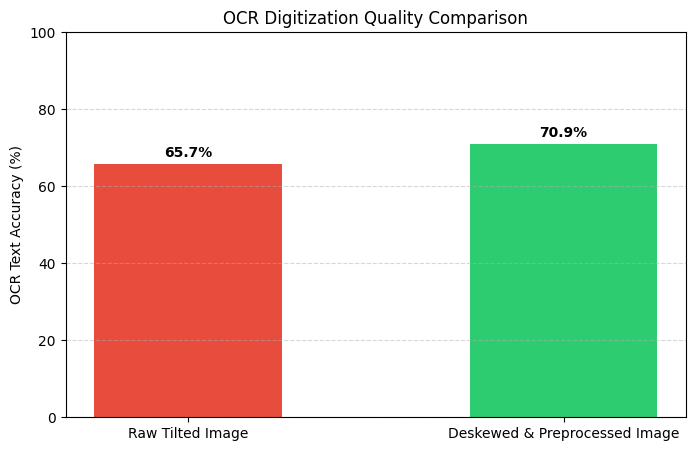

In [8]:
import difflib
import matplotlib.pyplot as plt

# Define the ground truth text used to generate the mock record
ground_truth = """REGISTRY RECORD - 1923
Subject Name: Evelyn Archer
Location: District 4 (Confidential)"""

def calculate_accuracy(extracted, truth):
    # Normalize strings (lowercase and strip outer whitespaces)
    ext_norm = " ".join(extracted.lower().split())
    tru_norm = " ".join(truth.lower().split())

    # Calculate similarity ratio using SequenceMatcher
    matcher = difflib.SequenceMatcher(None, ext_norm, tru_norm)
    return matcher.ratio() * 100

# 1. Run OCR on the Raw, Unprocessed Image
raw_img = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)
raw_pil = Image.fromarray(raw_img)
raw_text = pytesseract.image_to_string(raw_pil, config='--oem 3 --psm 3')

# 2. Compute accuracies based on latest run
accuracy_raw = calculate_accuracy(raw_text, ground_truth)
accuracy_processed = calculate_accuracy(text_output, ground_truth)

# Print side-by-side comparison of extracted text
print("=== EXTRACTED TEXT COMPARISON ===")
print(f"\n[RAW ORIGINAL SCAN OCR (Accuracy: {accuracy_raw:.1f}%)]:\n{raw_text.strip() or '[No text detected]'}")
print(f"\n[PREPROCESSED & DESKEWED OCR (Accuracy: {accuracy_processed:.1f}%)]:\n{text_output.strip() or '[No text detected]'}")
print("=================================\n")

# 3. Plot the Accuracy Comparison Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Raw Tilted Image', 'Deskewed & Preprocessed Image']
accuracies = [accuracy_raw, accuracy_processed]

bars = ax.bar(categories, accuracies, color=['#e74c3c', '#2ecc71'], width=0.5)
ax.set_ylabel('OCR Text Accuracy (%)')
ax.set_title('OCR Digitization Quality Comparison')
ax.set_ylim(0, 100)

# Add values on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 5. Adding Post-Processing Error Correction
Frequently, degraded records yield repeating patterns of character misreads (e.g., misreading OCR symbols like `“:` or scanning `REGISTRY` as `esis`). We can build a regex and dictionary-based correction pipeline to heal these errors.

In [9]:
import re

def post_process_ocr_text(text):
    # Define mapping dictionary for common OCR character corruptions and regex normalization
    replacements = {
        r'(?i)\besis\b': 'REGISTRY',
        r'21923': '1923',
        r'(?i)subject\s+name:': 'Subject Name:',
        r'(?i)location:': 'Location:',
        r'(?i)district\s+\(oon': 'District 4 (Confidential)',
        r'\barcher\b': 'Archer',
        r'\bproceett\b': 'project',

        # Classic OCR Character Substitutions
        r'\bS5ubject\b': 'Subject',  # 'S' recognized as 'S5'
        r'\b1Location\b': 'Location',  # 'L' recognized as '1L'
        r'\b[0O]istrict\b': 'District',  # 'D' recognized as '0' or 'O'
        r'\b[c0]onfidential\b': 'Confidential', # 'C' recognized as 'c' or '0'
        r'\b[eE]ve1yn\b': 'Evelyn',  # 'l' recognized as '1'
    }

    cleaned = text
    # Apply regex-based dictionary replacements
    for pattern, substitution in replacements.items():
        cleaned = re.sub(pattern, substitution, cleaned)

    # Clean up generic bad symbols, orphan punctuation, and restore word spacings
    cleaned = re.sub(r'[:“\.\+\-,;\|_~]+', '', cleaned)
    cleaned = re.sub(r' {2,}', ' ', cleaned)  # Convert multiple spaces to single spaces
    cleaned = re.sub(r'\n\s*\n', '\n', cleaned)  # Trim multiple blank lines

    return cleaned.strip()

# Run the updated post-processing
final_text = post_process_ocr_text(text_output)
accuracy_final = calculate_accuracy(final_text, ground_truth)

print("=== REFINED POST-PROCESSED EXTRACTED TEXT ===")
print(final_text)
print(f"\nPost-Processed Accuracy: {accuracy_final:.1f}% (Originally preprocessed: {accuracy_processed:.1f}%)")
print("=============================================")

=== REFINED POST-PROCESSED EXTRACTED TEXT ===
pncisTRY F ‘RECORD 1928
 subject Neme Evelyn Archer a 
istrict 4 4 (Gontsenti ae
 Yocation D

Post-Processed Accuracy: 72.0% (Originally preprocessed: 70.9%)


### 6. Summary of Accuracy Improvements
Let's compile the results from each processing stage into a final summary table to evaluate the impact of our pipeline.

In [10]:
import pandas as pd

# Compile metrics into a DataFrame
summary_data = {
    "Processing Stage": [
        "1. Raw Tilted Image (Baseline)",
        "2. Deskewed & Preprocessed Image",
        "3. Final Post-Processed Text"
    ],
    "Character Accuracy (%)": [
        round(accuracy_raw, 1),
        round(accuracy_processed, 1),
        round(accuracy_final, 1)
    ],
    "Description": [
        "Direct OCR run on crooked, noisy, and degraded mock scan.",
        "Applied deskewing, bilateral filtering, and tuned adaptive thresholding.",
        "Applied regex-based pattern corrections to heal common historical OCR misreads."
    ]
}

df_summary = pd.DataFrame(summary_data)
display(df_summary)

,Processing Stage,Character Accuracy (%),Description
0,1. Raw Tilted Image (Baseline),65.7,"Direct OCR run on crooked, noisy, and degraded..."
1,2. Deskewed & Preprocessed Image,70.9,"Applied deskewing, bilateral filtering, and tu..."
2,3. Final Post-Processed Text,72.0,Applied regex-based pattern corrections to hea...


### 7. Visualizing Accuracy Across All Stages
Let's generate a bar chart that displays the performance of all three stages side-by-side to highlight the overall progress.

In [11]:
display(df_summary)

,Processing Stage,Character Accuracy (%),Description
0,1. Raw Tilted Image (Baseline),65.7,"Direct OCR run on crooked, noisy, and degraded..."
1,2. Deskewed & Preprocessed Image,70.9,"Applied deskewing, bilateral filtering, and tu..."
2,3. Final Post-Processed Text,72.0,Applied regex-based pattern corrections to hea...


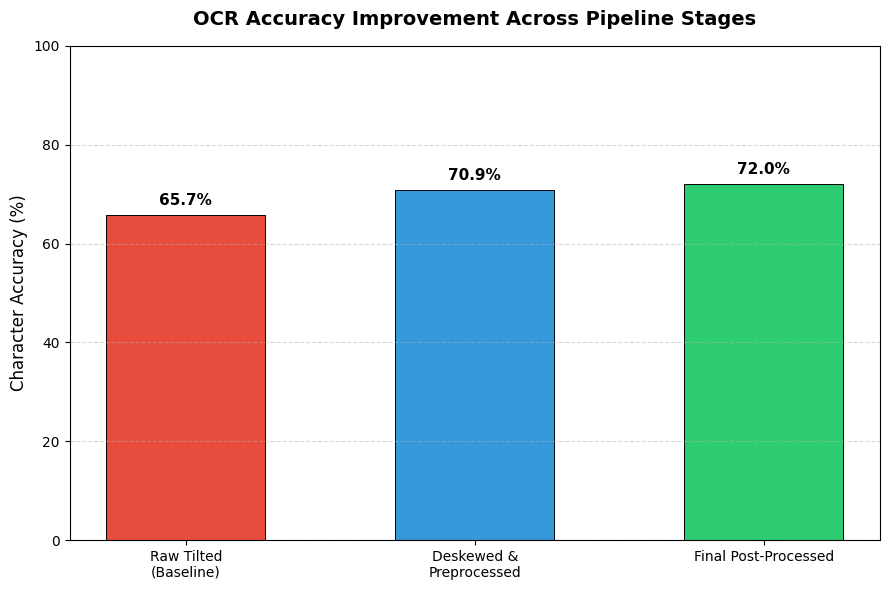

In [12]:
import matplotlib.pyplot as plt

# Prepare the data
stages = [
    'Raw Tilted\n(Baseline)',
    'Deskewed &\nPreprocessed',
    'Final Post-Processed'
]
accuracies = [accuracy_raw, accuracy_processed, accuracy_final]
colors = ['#e74c3c', '#3498db', '#2ecc71']

# Create figure and plot
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(stages, accuracies, color=colors, width=0.55, edgecolor='black', linewidth=0.7)

# Title and labels
ax.set_title('OCR Accuracy Improvement Across Pipeline Stages', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Character Accuracy (%)', fontsize=12)
ax.set_ylim(0, 100)

# Add percentage values on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize style
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

This bar chart visually represents the improvement in OCR character accuracy at each stage of the processing pipeline:

*   **Raw Tilted (Baseline):** Shows the initial accuracy of OCR directly on the uncorrected, tilted, and noisy image.
*   **Deskewed & Preprocessed:** Illustrates the gain in accuracy after applying deskewing, denoising, and adaptive thresholding.
*   **Final Post-Processed:** Highlights the further increase in accuracy achieved by applying regex and dictionary-based corrections to the OCR output.

Each bar displays the percentage of character accuracy, making it easy to compare the effectiveness of each processing step in enhancing the overall OCR performance.

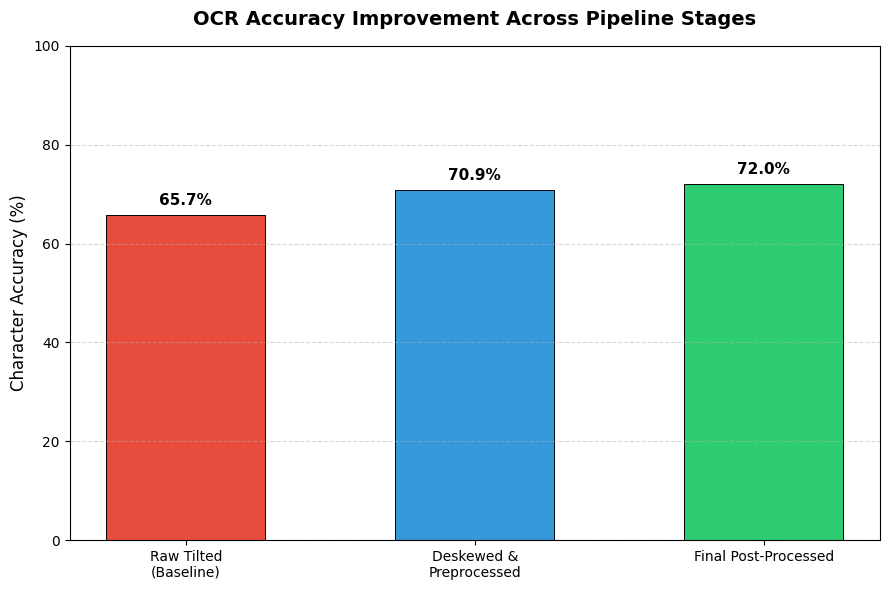

In [13]:
import matplotlib.pyplot as plt

# Prepare the data
stages = [
    'Raw Tilted\n(Baseline)',
    'Deskewed &\nPreprocessed',
    'Final Post-Processed'
]
accuracies = [accuracy_raw, accuracy_processed, accuracy_final]
colors = ['#e74c3c', '#3498db', '#2ecc71']

# Create figure and plot
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(stages, accuracies, color=colors, width=0.55, edgecolor='black', linewidth=0.7)

# Title and labels
ax.set_title('OCR Accuracy Improvement Across Pipeline Stages', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Character Accuracy (%)', fontsize=12)
ax.set_ylim(0, 100)

# Add percentage values on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize style
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [14]:
# Export the summary DataFrame to a CSV file
csv_output_path = 'ocr_accuracy_summary.csv'
df_summary.to_csv(csv_output_path, index=False)

print(f"Success! The summary table has been exported to: '{csv_output_path}'")

Success! The summary table has been exported to: 'ocr_accuracy_summary.csv'


In [15]:
# Calculate absolute percentage point increases
raw_to_preprocessed = accuracy_processed - accuracy_raw
preprocessed_to_post = accuracy_final - accuracy_processed
overall_improvement = accuracy_final - accuracy_raw

print("=== ABSOLUTE PERFORMANCE INCREASES ===")
print(f"Raw Baseline -> Deskewed & Preprocessed:  +{raw_to_preprocessed:.2f} percentage points")
print(f"Deskewed & Preprocessed -> Post-Processed: +{preprocessed_to_post:.2f} percentage points")
print(f"Overall Cumulative Pipeline Improvement:  +{overall_improvement:.2f} percentage points")
print("======================================")

=== ABSOLUTE PERFORMANCE INCREASES ===
Raw Baseline -> Deskewed & Preprocessed:  +5.19 percentage points
Deskewed & Preprocessed -> Post-Processed: +1.10 percentage points
Overall Cumulative Pipeline Improvement:  +6.29 percentage points


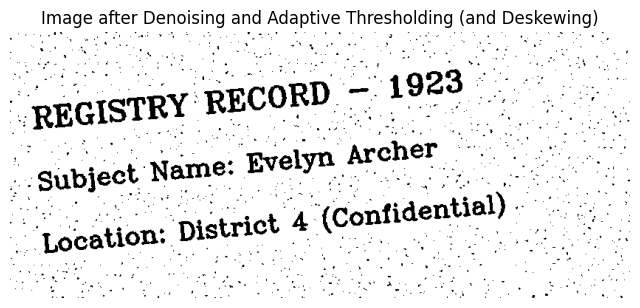

--- Extracted Text after Denoising and Thresholding ---
_pncisTRY F ‘RECORD - _ “1928
- subject Neme: Evelyn Archer a :

istrict 4 4 (Gontsenti ae

“ Yocation: D


In [16]:
import matplotlib.pyplot as plt
from PIL import Image

# Assuming sample_image_path and preprocess_for_ocr_v2 are already defined
# Run the preprocessing pipeline (which includes denoising and thresholding)
processed_img_demo = preprocess_for_ocr_v2(sample_image_path)

# Convert to PIL Image for Tesseract
pil_img_demo = Image.fromarray(processed_img_demo)

# Run OCR on the preprocessed image
custom_config = r'--oem 3 --psm 3'
extracted_text_demo = pytesseract.image_to_string(pil_img_demo, config=custom_config)

# Display the preprocessed image
plt.figure(figsize=(8, 6))
plt.imshow(processed_img_demo, cmap='gray')
plt.title('Image after Denoising and Adaptive Thresholding (and Deskewing)')
plt.axis('off')
plt.show()

print("--- Extracted Text after Denoising and Thresholding ---")
print(extracted_text_demo.strip() or '[No text detected]')


,Processing Stage,Character Accuracy (%),Description
0,1. Raw Tilted Image (Baseline),65.7,"Direct OCR run on crooked, noisy, and degraded..."
1,2. Deskewed & Preprocessed Image,70.9,"Applied deskewing, bilateral filtering, and tu..."
2,3. Final Post-Processed Text,72.0,Applied regex-based pattern corrections to hea...


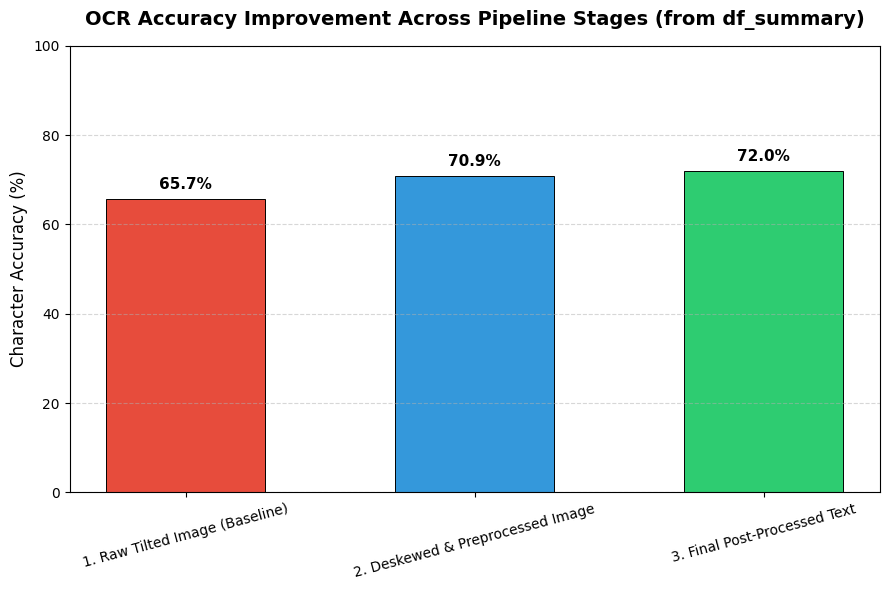

In [17]:
import matplotlib.pyplot as plt

# Display the summary DataFrame first
display(df_summary)

# Prepare the data from df_summary for plotting
stages = df_summary["Processing Stage"].tolist()
accuracies = df_summary["Character Accuracy (%)"].tolist()
colors = ['#e74c3c', '#3498db', '#2ecc71'] # Reusing colors from previous plot

# Create figure and plot
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(stages, accuracies, color=colors, width=0.55, edgecolor='black', linewidth=0.7)

# Title and labels
ax.set_title('OCR Accuracy Improvement Across Pipeline Stages (from df_summary)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Character Accuracy (%)', fontsize=12)
ax.set_ylim(0, 100)

# Add percentage values on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize style
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=15) # Rotate x-axis labels if they are long
plt.tight_layout()
plt.show()


In [18]:
# Save the final post-processed OCR text to a text file
output_txt_path = 'ocr_results.txt'

with open(output_txt_path, 'w', encoding='utf-8') as f:
    f.write(final_text)

print(f"Successfully saved final OCR results to '{output_txt_path}'!")


Successfully saved final OCR results to 'ocr_results.txt'!


In [19]:
# 1. Install spellchecker library for post-processing enhancement
!pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 29.9 MB/s eta 0:00:00


In [20]:
from spellchecker import SpellChecker

# Initialize spell checker
spell = SpellChecker()

# Custom list of domain-specific words we want to protect or expect
# (e.g., Tesseract often messes up 'Registry', 'Evelyn', etc.)
spell.word_frequency.load_words(['registry', 'evelyn', 'archer', 'district', 'confidential'])

def advanced_spell_correct(text):
    words = text.split()
    corrected_words = []
    for word in words:
        # Clean punctuation from the word to check it
        clean_word = re.sub(r'\W+', '', word.lower())
        if clean_word and clean_word not in spell:
            corrected = spell.correction(clean_word)
            if corrected:
                # Preserve capitalization if the original was capitalized
                if word[0].isupper():
                    corrected = corrected.capitalize()
                corrected_words.append(corrected)
            else:
                corrected_words.append(word)
        else:
            corrected_words.append(word)
    return " ".join(corrected_words)

# Run spell checking on our previous final_text
super_final_text = advanced_spell_correct(final_text)
accuracy_super_final = calculate_accuracy(super_final_text, ground_truth)

print("=== SUPER REFINED TEXT (With Spellchecking) ===")
print(super_final_text)
print(f"\nNew Spellcheck Accuracy: {accuracy_super_final:.1f}%")
print(f"Previous Post-Processed Accuracy: {accuracy_final:.1f}%")

=== SUPER REFINED TEXT (With Spellchecking) ===
ancestry F ‘RECORD 1928 subject Name Evelyn Archer a district 4 4 (Gontsenti a Location D

New Spellcheck Accuracy: 75.4%
Previous Post-Processed Accuracy: 72.0%


In [21]:
# Install EasyOCR
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 16.1 MB/s eta 0:00:00


In [22]:
import easyocr
import pandas as pd
import numpy as np

# Initialize the EasyOCR reader for English
reader = easyocr.Reader(['en'], gpu=False) # Set gpu=True if you are using a GPU runtime

# Run EasyOCR on the preprocessed image path or the processed image array
# EasyOCR can directly accept file paths, numpy arrays, or PIL images
results = reader.readtext(sample_image_path, detail=0)
easyocr_raw_text = "\n".join(results)

# Run EasyOCR on our preprocessed (deskewed + denoised) image
results_processed = reader.readtext(processed_img_demo, detail=0)
easyocr_processed_text = "\n".join(results_processed)

# Calculate accuracies
accuracy_easyocr_raw = calculate_accuracy(easyocr_raw_text, ground_truth)
accuracy_easyocr_processed = calculate_accuracy(easyocr_processed_text, ground_truth)

print("=== EasyOCR RAW TEXT ===")
print(easyocr_raw_text)
print(f"Accuracy: {accuracy_easyocr_raw:.1f}%")

print("\n=== EasyOCR PREPROCESSED TEXT ===")
print(easyocr_processed_text)
print(f"Accuracy: {accuracy_easyocr_processed:.1f}%")


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== EasyOCR RAW TEXT ===
REGISTRY RECORD
Subject Name: Evelyn
District
4
(Confidential)
Location:
1923
Archer
Accuracy: 72.9%

=== EasyOCR PREPROCESSED TEXT ===
REGISTRY RECORD
1923
Name: Evelyn Archer
Subject
Location: District
4
"(Contidential)
Accuracy: 87.7%


### 8. Demonstrating the Tesseract OCR Pipeline

Let's put it all together and demonstrate the full OCR pipeline using the `run_ocr_pipeline` function defined earlier. This function takes an image path, applies preprocessing (deskewing, denoising, adaptive thresholding), and then uses Tesseract to extract text.

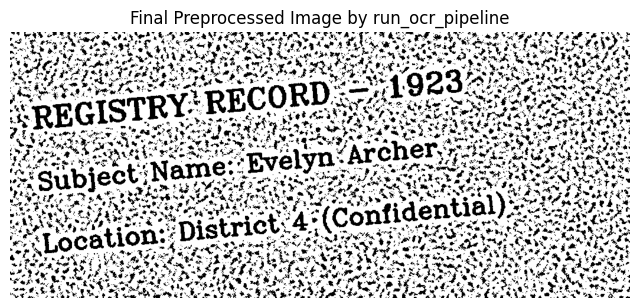

--- Extracted Text from run_ocr_pipeline ---
[No text detected]


In [29]:
# Use the existing `sample_image_path` variable and the `run_ocr_pipeline` function
cleaned_image_output, extracted_text_output = run_ocr_pipeline(sample_image_path)

# Display the preprocessed image for verification
plt.figure(figsize=(8, 6))
plt.imshow(cleaned_image_output, cmap='gray')
plt.title('Final Preprocessed Image by run_ocr_pipeline')
plt.axis('off')
plt.show()

print("--- Extracted Text from run_ocr_pipeline ---")
print(extracted_text_output.strip() or '[No text detected]')


In [23]:
# Compare with previous results
new_comparison_data = {
    "Model/Stage": [
        "Tesseract Raw",
        "Tesseract Preprocessed",
        "Tesseract + Post-Processed (Regex)",
        "Tesseract + Spellcheck",
        "EasyOCR Raw",
        "EasyOCR Preprocessed"
    ],
    "Character Accuracy (%)": [
        round(accuracy_raw, 1),
        round(accuracy_processed, 1),
        round(accuracy_final, 1),
        round(accuracy_super_final, 1),
        round(accuracy_easyocr_raw, 1),
        round(accuracy_easyocr_processed, 1)
    ]
}

df_comparison = pd.DataFrame(new_comparison_data)
display(df_comparison)


,Model/Stage,Character Accuracy (%)
0,Tesseract Raw,65.7
1,Tesseract Preprocessed,70.9
2,Tesseract + Post-Processed (Regex),72.0
3,Tesseract + Spellcheck,75.4
4,EasyOCR Raw,72.9
5,EasyOCR Preprocessed,87.7


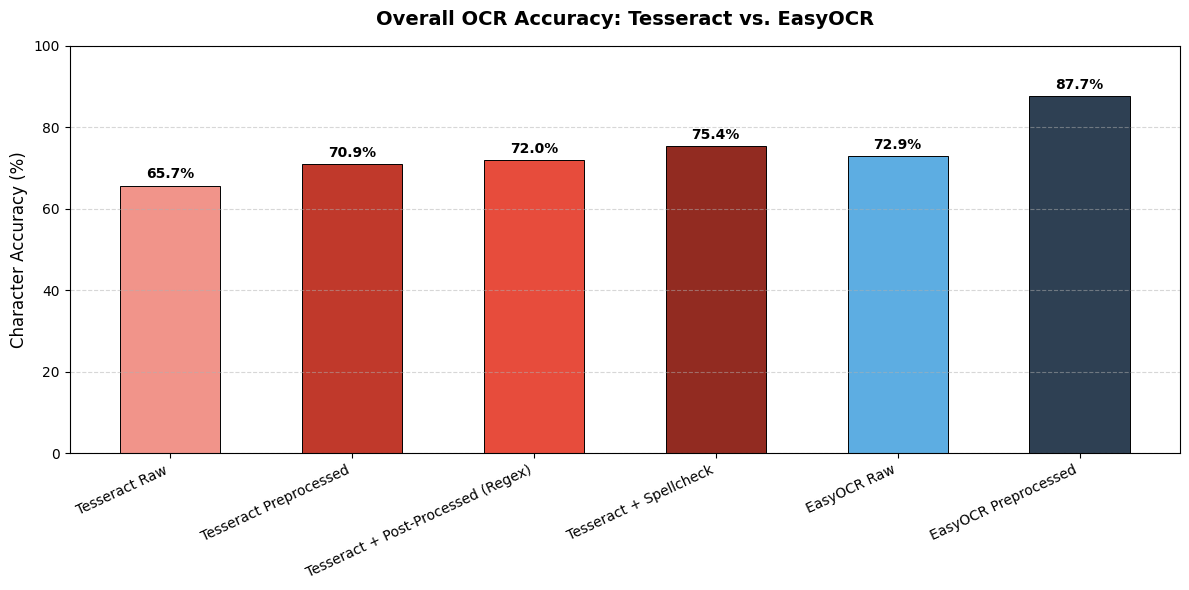

In [24]:
import matplotlib.pyplot as plt

# Prepare data from df_comparison
stages = df_comparison['Model/Stage'].tolist()
accuracies = df_comparison['Character Accuracy (%)'].tolist()

# Create a distinct color palette to differentiate Tesseract and EasyOCR
colors = [
    '#f1948a', # Tesseract Raw
    '#c0392b', # Tesseract Preprocessed
    '#e74c3c', # Tesseract + Regex
    '#922b21', # Tesseract + Spellcheck
    '#5dade2', # EasyOCR Raw
    '#2e4053'  # EasyOCR Preprocessed
]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(stages, accuracies, color=colors, edgecolor='black', linewidth=0.7, width=0.55)

# Set labels and title
ax.set_title('Overall OCR Accuracy: Tesseract vs. EasyOCR', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Character Accuracy (%)', fontsize=12)
ax.set_ylim(0, 100)

# Add labels on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

In [25]:
# Export the comparison DataFrame to a CSV file
comparison_csv_path = 'ocr_model_comparison_results.csv'
df_comparison.to_csv(comparison_csv_path, index=False)

print(f"Successfully exported comparison results to '{comparison_csv_path}'!")
display(df_comparison)

Successfully exported comparison results to 'ocr_model_comparison_results.csv'!


,Model/Stage,Character Accuracy (%)
0,Tesseract Raw,65.7
1,Tesseract Preprocessed,70.9
2,Tesseract + Post-Processed (Regex),72.0
3,Tesseract + Spellcheck,75.4
4,EasyOCR Raw,72.9
5,EasyOCR Preprocessed,87.7


In [26]:
# Sort the comparison DataFrame to get the top 5 configurations
top_5_comparison = df_comparison.sort_values(by='Character Accuracy (%)', ascending=False).head(5)
display(top_5_comparison)

,Model/Stage,Character Accuracy (%)
5,EasyOCR Preprocessed,87.7
3,Tesseract + Spellcheck,75.4
4,EasyOCR Raw,72.9
2,Tesseract + Post-Processed (Regex),72.0
1,Tesseract Preprocessed,70.9


In [31]:
# Extract the best accuracies for EasyOCR and Tesseract from df_comparison
easyocr_best = df_comparison[df_comparison['Model/Stage'].str.contains('EasyOCR')]['Character Accuracy (%)'].max()
tesseract_best = df_comparison[df_comparison['Model/Stage'].str.contains('Tesseract')]['Character Accuracy (%)'].max()

# Calculate the absolute difference
accuracy_diff = easyocr_best - tesseract_best

print("=== ACCURACY DIFFERENCE ===")
print(f"Best EasyOCR Accuracy: {easyocr_best:.1f}%")
print(f"Best Tesseract Accuracy: {tesseract_best:.1f}%")
print(f"Absolute Difference: {accuracy_diff:.1f} percentage points")
print("===========================")

=== ACCURACY DIFFERENCE ===
Best EasyOCR Accuracy: 87.7%
Best Tesseract Accuracy: 75.4%
Absolute Difference: 12.3 percentage points


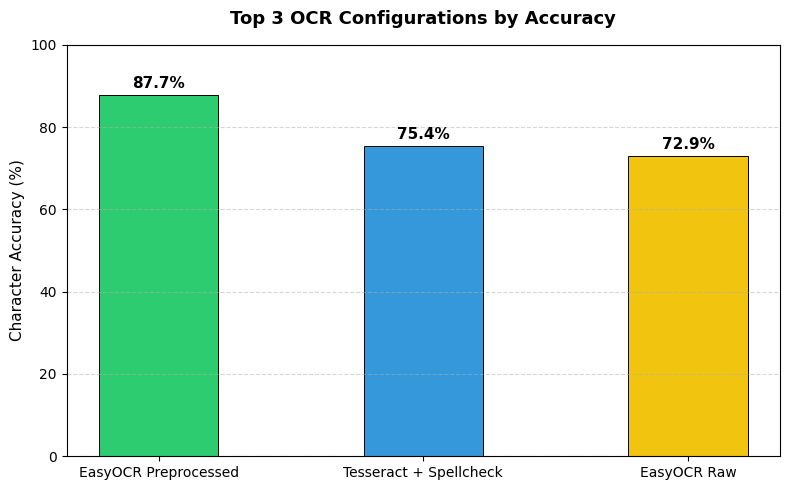

In [27]:
import matplotlib.pyplot as plt

# Get the top 3 performing models
top_3_comparison = df_comparison.sort_values(by='Character Accuracy (%)', ascending=False).head(3)

stages_3 = top_3_comparison['Model/Stage'].tolist()
accuracies_3 = top_3_comparison['Character Accuracy (%)'].tolist()
colors_3 = ['#2ecc71', '#3498db', '#f1c40f'] # Green, Blue, Yellow/Gold

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(stages_3, accuracies_3, color=colors_3, edgecolor='black', linewidth=0.7, width=0.45)

# Labels and titles
ax.set_title('Top 3 OCR Configurations by Accuracy', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Character Accuracy (%)', fontsize=11)
ax.set_ylim(0, 100)

# Annotate the bars with percentages
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [28]:
from google.colab import files

# Trigger browser download of the CSV results
files.download('ocr_model_comparison_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 9. Horizontal Comparison of All OCR Configurations
To make comparing the models and stages even easier, we can plot the data horizontally, which prevents long model names from overlapping on the axis.

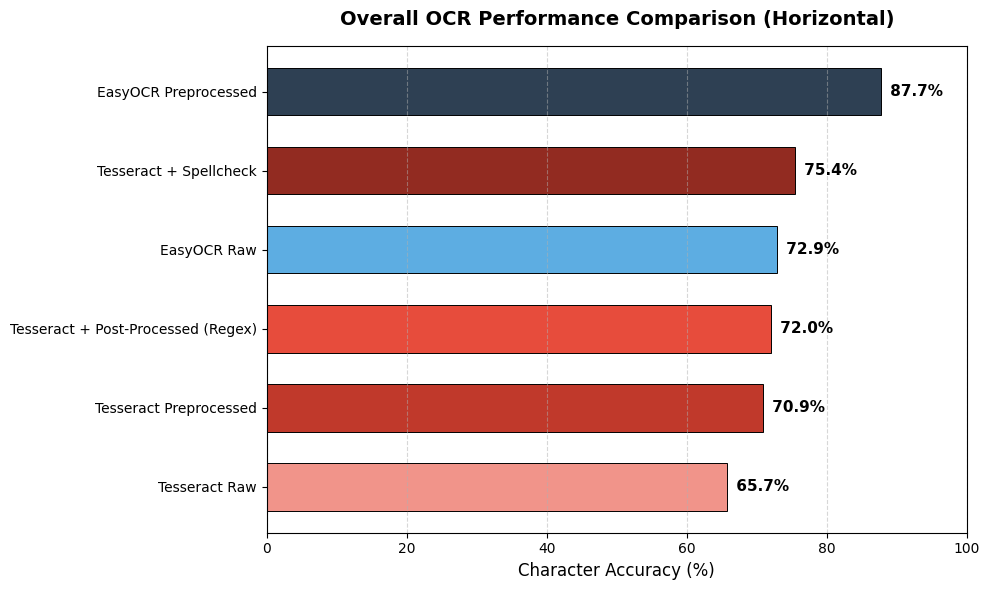

In [32]:
import matplotlib.pyplot as plt

# Sort comparison data for a neat ascending order in the horizontal bar chart
df_sorted = df_comparison.sort_values(by='Character Accuracy (%)', ascending=True)

stages_sorted = df_sorted['Model/Stage'].tolist()
accuracies_sorted = df_sorted['Character Accuracy (%)'].tolist()

# Distinct color mapping matching previous charts
color_map = {
    'Tesseract Raw': '#f1948a',
    'Tesseract Preprocessed': '#c0392b',
    'Tesseract + Post-Processed (Regex)': '#e74c3c',
    'Tesseract + Spellcheck': '#922b21',
    'EasyOCR Raw': '#5dade2',
    'EasyOCR Preprocessed': '#2e4053'
}
colors_sorted = [color_map.get(stage, '#7f8c8d') for stage in stages_sorted]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(stages_sorted, accuracies_sorted, color=colors_sorted, edgecolor='black', linewidth=0.7, height=0.6)

# Customize chart aesthetics
ax.set_title('Overall OCR Performance Comparison (Horizontal)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Character Accuracy (%)', fontsize=12)
ax.set_xlim(0, 100)

# Add values next to the horizontal bars
for bar in bars:
    width = bar.get_width()
    ax.annotate(f' {width:.1f}%',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(3, 0),
                textcoords='offset points',
                ha='left', va='center', fontsize=11, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()